# Bayesian Optimization with AFL Pipelines

This tutorial shows an end-to-end Bayesian optimization campaign that stays native to the AFL pipeline API while using the BoTorch-backed `BoTorchRegressor` and `BoTorchAcquisition` ops.

Each optimization round runs the same AFL `Pipeline` on the current `xarray.Dataset`, reads the recommended next sample from the pipeline outputs, evaluates a BoTorch standard test function, and appends the new observation back into the dataset.

The notebook is written for low-dimensional synthetic objectives from `botorch.test_functions.synthetic`, such as `Branin`, `Ackley`, and `Hartmann`.

## 1. Set Up the Environment

Import the libraries used for the optimization campaign, configure plotting, and set a reproducible random seed.

In [1]:
# Uncomment this cell if you need to install AFL-agent with BoTorch support.
# !pip install -e .[botorch]

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from AFL.double_agent import (
    Pipeline,
    CartesianGrid,
    Standardize,
    BoTorchRegressor,
    BoTorchAcquisition,
)


plt.style.use("seaborn-v0_8-whitegrid")

rng = np.random.default_rng(7)
np.set_printoptions(precision=4, suppress=True)

## 2. Define the Objective Function

BoTorch ships a collection of standard synthetic test functions. The helper below loads one by name, exposes its bounds, and evaluates it on NumPy arrays while preserving the original objective convention.

In [3]:
def load_test_function(name: str):
    from botorch.test_functions import synthetic
    if not hasattr(synthetic, name):
        available = sorted(
            candidate
            for candidate in dir(synthetic)
            if candidate and candidate[0].isupper()
        )

        raise ValueError(f"Unknown BoTorch synthetic function '{name}'. Try one of: {available[:20]}")

    function_cls = getattr(synthetic, name)
    test_function = function_cls(negate=False)
    bounds = test_function.bounds.detach().cpu().numpy().T
    dimension = bounds.shape[0]
    def evaluate(points: np.ndarray) -> np.ndarray:
        points = np.asarray(points, dtype=float)
        if points.ndim == 1:
            points = points[None, :]
        values = test_function(
            __import__("torch").as_tensor(points, dtype=__import__("torch").double)
        )
        return values.detach().cpu().numpy().reshape(-1)
    return test_function, bounds, dimension, evaluate

function_name = "Branin"
test_function, bounds, dimension, evaluate_objective = load_test_function(function_name)
n_initial = 6
n_iterations = 12
if dimension == 1:
    grid_axis = np.linspace(bounds[0, 0], bounds[0, 1], 401)
    candidate_grid = grid_axis[:, None]
elif dimension == 2:
    axis_0 = np.linspace(bounds[0, 0], bounds[0, 1], 81)
    axis_1 = np.linspace(bounds[1, 0], bounds[1, 1], 81)
    mesh_0, mesh_1 = np.meshgrid(axis_0, axis_1, indexing="ij")
    candidate_grid = np.column_stack([mesh_0.ravel(), mesh_1.ravel()])
else:
    raise ValueError(
        f"This tutorial currently supports only 1D or 2D functions, but {function_name} has dimension {dimension}."
    )

initial_x = rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_initial, dimension))
initial_y = evaluate_objective(initial_x)
candidate_grid.shape, initial_x.shape
print(f"Objective function: {function_name} has bounds {bounds} \n"
      f"and global minimum value {test_function.optimal_value:.4f} at \n"
      f"{test_function.optimizers.cpu().numpy()}")

Objective function: Branin has bounds [[-5. 10.]
 [ 0. 15.]] 
and global minimum value 0.3979 at 
[[-3.1416 12.275 ]
 [ 3.1416  2.275 ]
 [ 9.4248  2.475 ]]


## 3. Specify the Search Space

Choose an initial design and build a dense candidate grid. This tutorial supports one- and two-dimensional BoTorch synthetic functions because the current AFL acquisition flow is grid-first.

In [4]:
from botorch.utils.sampling import draw_sobol_samples

n_initial = 6
n_iterations = 12

if dimension > 2:
    raise ValueError(
        f"This tutorial currently supports only 1D or 2D functions, but {function_name} has dimension {dimension}."
    )

component_names = [f"x{i}" for i in range(dimension)]

sobol_bounds = __import__("torch").as_tensor(bounds.T, dtype=__import__("torch").double)
initial_x = (
    draw_sobol_samples(bounds=sobol_bounds, n=1, q=n_initial)
    .squeeze(0)
    .detach()
    .cpu()
    .numpy()
)
initial_y = evaluate_objective(initial_x)

print(f"Initial samples:\n{pd.DataFrame(initial_x, columns=component_names).assign(objective=initial_y)}")

Initial samples:
         x0         x1  objective
0 -1.226229  13.312706  39.939879
1 -0.003813  10.810564  42.685206
2  3.075113   4.016787   3.273073
3  9.501563   3.355115   1.089726
4  7.971233   4.313835  16.671937
5  2.277620   2.846381   3.803713


In [5]:
component_names = [f"x{i}" for i in range(dimension)]

initial_dataset = xr.Dataset(
    data_vars={
        "composition": (("sample", "component"), initial_x),
        "objective": ("sample", initial_y),
    },
    coords={"component": component_names},
)
initial_dataset

<xarray.Dataset> Size: 160B
Dimensions:      (sample: 6, component: 2)
Coordinates:
  * component    (component) <U2 16B 'x0' 'x1'
Dimensions without coordinates: sample
Data variables:
    composition  (sample, component) float64 96B -1.226 13.31 ... 2.278 2.846
    objective    (sample) float64 48B 39.94 42.69 3.273 1.09 16.67 3.804

## 4. Run Bayesian Optimization

Define a reusable AFL pipeline and execute it repeatedly. The pipeline itself stays fixed; only the dataset grows as new observations are appended.

In [6]:
grid_spec = {
    name: {"min": float(lo), "max": float(hi), "steps": 20}
    for name, (lo, hi) in zip(component_names, bounds.tolist())
}

with Pipeline() as bayesopt_pipeline:
    CartesianGrid(
        output_variable="composition_grid_raw",
        grid_spec=grid_spec,
        sample_dim="grid",
        component_dim="component",
    )

    Standardize(
        input_variable="composition",
        output_variable="composition_std",
        dim="grid",
        component_dim="component",
        scale_variable="composition_grid_raw",
    )

    Standardize(
        input_variable="composition_grid_raw",
        output_variable="composition_grid",
        dim="grid",
        component_dim="component",
    )

    BoTorchRegressor(
        feature_input_variable="composition_std",
        predictor_input_variable="objective",
        grid_variable="composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        output_prefix="botorch",
        objective_direction="minimize",
        posterior_optimize=True,
    )

    BoTorchAcquisition(
        feature_input_variable="composition_std",
        predictor_input_variable="objective",
        grid_variable="composition_grid",
        grid_dim="grid",
        sample_dim="sample",
        objective_direction="minimize",
        acquisition_kind="qlogei",
        best_f_variable="botorch_best_f",
        output_prefix="botorch",
        decision_rtol=1.0,
        count=1,
    )

In [7]:
history = []
campaign_dataset = initial_dataset.copy()

for iteration in range(n_iterations):
    result = bayesopt_pipeline.calculate(campaign_dataset, disable_progress_bar=True)
    suggested_x = np.asarray(result["next_samples"].values, dtype=float).reshape(1, dimension)
    suggested_y = evaluate_objective(suggested_x)

    history.append(
        {
            "iteration": iteration,
            "suggested_x": suggested_x[0].tolist(),
            "objective": float(suggested_y[0]),
            "best_observed": float(np.min(campaign_dataset["objective"].values)),
            "best_posterior": float(np.asarray(result["botorch_best_f"].values).reshape(-1)[0]),
            "best_posterior_location": np.asarray(result["botorch_best_x"].values, dtype=float).reshape(-1).tolist(),
        }
    )

    updated_x = np.vstack([campaign_dataset["composition"].values, suggested_x])
    updated_y = np.concatenate([campaign_dataset["objective"].values, suggested_y])

    campaign_dataset = xr.Dataset(
        data_vars={
            "composition": (("sample", "component"), updated_x),
            "objective": ("sample", updated_y),
        },
        coords={
            "sample": np.arange(updated_x.shape[0]),
            "component": component_names,
        },
    )

history_df = pd.DataFrame(history)
history_df.head(n_iterations)

,iteration,suggested_x,objective,best_observed,best_posterior,best_posterior_location
0,0,"[0.7894736842105263, 0.7894736842105263]",33.039638,1.089726,1.956761,"[1.0, 0.15737593747883385]"
1,1,"[0.15789473684210525, 0.8421052631578948]",43.588981,1.089726,0.005787,"[0.9984760049501982, 0.2038248496128911]"
2,2,"[0.6842105263157895, 0.15789473684210525]",40.611861,1.089726,0.397046,"[1.0, 0.19851366386943659]"
3,3,"[0.10526315789473685, 1.0]",42.915553,1.089726,0.229069,"[1.0, 0.19862837331283026]"
4,4,"[0.4210526315789474, 0.7894736842105263]",39.587189,1.089726,0.406316,"[1.0, 0.19737794113652057]"
5,5,"[0.05263157894736844, 0.8421052631578948]",45.339233,1.089726,0.508442,"[1.0, 0.1969491764955195]"
6,6,"[0.7368421052631579, 0.8947368421052632]",33.132728,1.089726,0.605192,"[1.0, 0.19641560037856276]"
7,7,"[0.05263157894736844, 0.9473684210526316]",44.282000,1.089726,0.409376,"[1.0, 0.1999386332390424]"
8,8,"[0.8421052631578948, 1.0]",30.466672,1.089726,0.438186,"[1.0, 0.19984742549902168]"
9,9,"[0.8947368421052632, 0.4736842105263158]",33.696329,1.089726,0.442097,"[1.0, 0.19993997268467015]"


In [12]:
result

<xarray.Dataset> Size: 26kB
Dimensions:                   (sample: 17, component: 2, grid: 400, AF_sample: 1)
Coordinates:
  * sample                    (sample) int64 136B 0 1 2 3 4 5 ... 12 13 14 15 16
  * component                 (component) <U2 16B 'x0' 'x1'
  * grid                      (grid) int64 3kB 0 1 2 3 4 ... 395 396 397 398 399
Dimensions without coordinates: AF_sample
Data variables:
    composition               (sample, component) float64 272B -1.226 ... 0.3158
    objective                 (sample) float64 136B 39.94 42.69 ... 33.7 37.09
    composition_grid_raw      (grid, component) float64 6kB -5.0 0.0 ... 15.0
    composition_std           (sample, component) float64 272B 0.2516 ... 0.0...
    composition_grid          (grid, component) float64 6kB 0.0 0.0 ... 1.0 1.0
    botorch_mean              (grid) float64 3kB -30.53 -30.38 ... -27.75 -27.81
    botorch_variance          (grid) float64 3kB 229.6 229.3 ... 232.8 232.8
    botorch_best_f            float64 8B 0.3971
    botorch_best_x            (component) float64 16B 1.0 0.2007
    botorch_decision_surface  (grid) float64 3kB 0.9474 0.9478 ... 0.9574 0.9572
    next_samples              (AF_sample, component) float64 16B 0.3158 0.3158

## 5. Inspect Best Parameters and Best Score

The objective values below are reported in the original BoTorch test-function convention, so lower is better for the standard minimization problems used here.

In [15]:
best_x = result["botorch_best_x"].values
best_y = float(result["botorch_best_f"].values)
print(f"Function: {function_name}")
print(f"Best objective: {best_y:.6f}")
print("Best parameters:", best_x)

Function: Branin
Best objective: 0.397145
Best parameters: [1.     0.2007]


## 6. Visualize Optimization Progress

Plot the best-so-far trace across iterations. For one-dimensional objectives, also compare the sampled points against the true objective and the final acquisition surface.

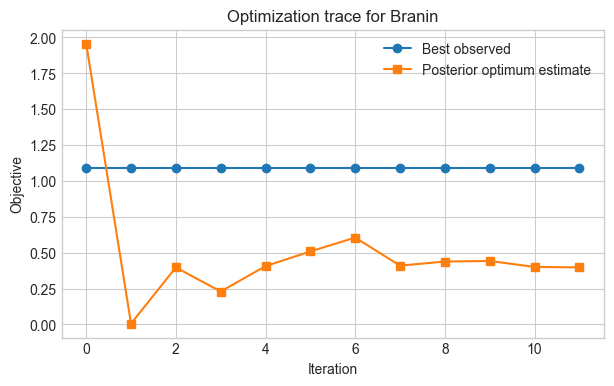

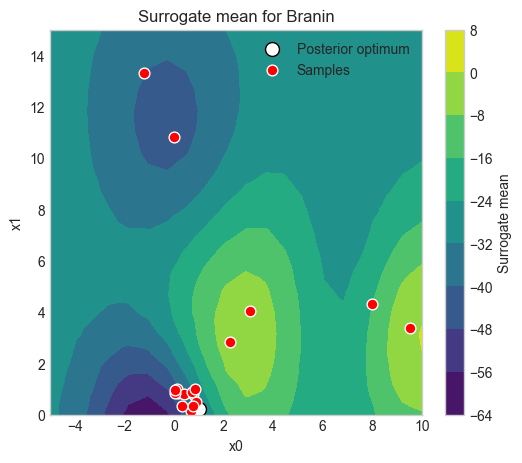

In [23]:
history_df["best_so_far"] = history_df["best_observed"].cummin()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["iteration"], history_df["best_so_far"], marker="o", label="Best observed")
ax.plot(history_df["iteration"], history_df["best_posterior"], marker="s", label="Posterior optimum estimate")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.set_title(f"Optimization trace for {function_name}")
ax.legend()
plt.show()

final_result = bayesopt_pipeline.calculate(campaign_dataset, disable_progress_bar=True)

if dimension == 1:
    grid_x = np.asarray(final_result["composition_grid_raw"].values, dtype=float)
    surrogate_mean = np.asarray(final_result["botorch_mean"].values, dtype=float)
    surrogate_var = np.asarray(final_result["botorch_variance"].values, dtype=float)
    acquisition = np.asarray(final_result["botorch_decision_surface"].values, dtype=float)
    
    x_plot = grid_x[:, 0]
    order = np.argsort(x_plot)
    
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    
    axes[0].plot(x_plot[order], evaluate_objective(grid_x)[order], label="True objective", color="black")
    axes[0].scatter(
        campaign_dataset["composition"].values[:, 0],
        campaign_dataset["objective"].values,
        color="tab:red",
        label="Samples",
    )
    axes[0].set_ylabel("Objective")
    axes[0].legend()
    
    axes[1].plot(x_plot[order], surrogate_mean[order], color="tab:blue", label="Surrogate mean")
    axes[1].fill_between(
        x_plot[order],
        surrogate_mean[order] - 2.0 * np.sqrt(surrogate_var[order]),
        surrogate_mean[order] + 2.0 * np.sqrt(surrogate_var[order]),
        color="tab:blue",
        alpha=0.2,
        label="Mean +/- 2 sigma",
    )
    axes[1].set_ylabel("Surrogate")
    axes[1].legend()
    
    axes[2].plot(x_plot[order], acquisition[order], color="tab:green", label="Acquisition")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("Decision surface")
    axes[2].legend()
    
    plt.show()

elif dimension == 2:
    final_result = bayesopt_pipeline.calculate(campaign_dataset, disable_progress_bar=True)
    
    grid_x = np.asarray(final_result["composition_grid_raw"].values, dtype=float)
    surrogate_mean = np.asarray(final_result["botorch_mean"].values, dtype=float)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.tricontourf(
        grid_x[:, 0],
        grid_x[:, 1],
        surrogate_mean,
        cmap="viridis",
    )
    ax.scatter(
        final_result["botorch_best_x"].values[0],
        final_result["botorch_best_x"].values[1],
        color="white",
        edgecolor="black",
        s=100,
        label="Posterior optimum",
    )
    ax.scatter(
        campaign_dataset["composition"].values[:, 0],
        campaign_dataset["composition"].values[:, 1],
        color="red",
        edgecolor="white",
        s=60,
        label="Samples",
    )
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.set_title(f"Surrogate mean for {function_name}")
    ax.legend()
    fig.colorbar(sc, ax=ax, label="Surrogate mean")
    plt.show()

## 7. Compare Suggested Configurations

Create a compact table of all evaluated points, sorted by objective value.

In [19]:
results_df = pd.DataFrame(
    campaign_dataset["composition"].values,
    columns=[str(feature) for feature in campaign_dataset.coords["component"].values],
)

results_df["objective"] = campaign_dataset["objective"].values
results_df = results_df.sort_values("objective", ascending=True).reset_index(drop=True)
results_df.head(10)

,x0,x1,objective
0,9.501563,3.355115,1.089726
1,3.075113,4.016787,3.273073
2,2.277620,2.846381,3.803713
3,7.971233,4.313835,16.671937
4,0.842105,1.000000,30.466672
5,0.789474,0.789474,33.039638
6,0.736842,0.894737,33.132728
7,0.894737,0.473684,33.696329
8,0.789474,0.315789,37.086226
9,0.421053,0.789474,39.587189
